In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Input
from keras import utils
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [2]:
matplotlib.style.use('ggplot')
%matplotlib inline

In [3]:
wine_collection_df = pd.read_csv('wine_collection.csv', sep = ';')

In [4]:
wine_collection_df.head()

,№,Alcohol,Malic and Apple Acid,Ash,Alcalinity of Ash,Magnesium,Total Phenols,Flavanoids,Nonflavanoid Phenols,Proanthocyanins,Color,Intensity,Hue,OD280_OD315_of_Deluted_Wines,Proline,Desired
0,1,13.34,2.43,2.49,11.24,107,2.95,3.00,0.35,1.95,White,7.16,1.04,2.97,843,2
1,2,14.13,2.02,2.74,12.08,129,3.31,2.71,0.26,2.08,Rosé,5.11,0.87,3.66,818,1
2,3,13.74,2.50,2.67,16.16,129,3.26,3.41,0.36,2.32,White,5.29,1.03,3.03,901,1
3,4,14.20,2.10,2.70,20.19,117,3.46,3.41,0.31,2.78,White,5.79,0.92,3.89,1146,2
4,5,14.22,2.35,2.17,13.80,128,3.23,2.99,0.37,2.42,Red,5.07,0.91,3.86,1227,2


In [5]:
if 'Color' in wine_collection_df.columns:
    del wine_collection_df['Color']
if '№' in wine_collection_df.columns:
    del wine_collection_df['№']

In [7]:
wine_collection_df.head()

,Alcohol,Malic and Apple Acid,Ash,Alcalinity of Ash,Magnesium,Total Phenols,Flavanoids,Nonflavanoid Phenols,Proanthocyanins,Intensity,Hue,OD280_OD315_of_Deluted_Wines,Proline,Desired
0,13.34,2.43,2.49,11.24,107,2.95,3.00,0.35,1.95,7.16,1.04,2.97,843,2
1,14.13,2.02,2.74,12.08,129,3.31,2.71,0.26,2.08,5.11,0.87,3.66,818,1
2,13.74,2.50,2.67,16.16,129,3.26,3.41,0.36,2.32,5.29,1.03,3.03,901,1
3,14.20,2.10,2.70,20.19,117,3.46,3.41,0.31,2.78,5.79,0.92,3.89,1146,2
4,14.22,2.35,2.17,13.80,128,3.23,2.99,0.37,2.42,5.07,0.91,3.86,1227,2


In [ ]:
wine_collection_df['Desired'].value_counts(normalize = True)

,proportion
Desired,
0,0.338
2,0.333
1,0.329


In [8]:
X = wine_collection_df.drop('Desired', axis = 1)
y = wine_collection_df['Desired']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 12345, test_size = 0.33)

In [10]:
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

In [11]:
y_train_bin = utils.to_categorical(y_train)
y_test_bin = utils.to_categorical(y_test)

In [12]:
y_train_bin[0:5]

array([[1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [13]:
model = Sequential()
model.add(Input(shape = (13,)))
model.add(Dense(9, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(3, activation='softmax'))
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])
model.fit(X_train, y_train_bin, epochs = 300, batch_size = 10)

Epoch 1/300
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3284 - loss: 97.5147 
Epoch 2/300
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3164 - loss: 19.9405
Epoch 3/300
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3343 - loss: 5.6904
Epoch 4/300
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3284 - loss: 2.6840
Epoch 5/300
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3164 - loss: 2.4766
Epoch 6/300
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3672 - loss: 2.2805
Epoch 7/300
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3358 - loss: 2.0369
Epoch 8/300
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3343 - loss: 1.9688
Epoch 9/300
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3657 - loss: 1.8194
Epoch 10/300
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3493 - loss: 1.8007
Epoch 11/300
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3493 - loss: 1.6676
Epoch 12/300
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accura

In [16]:
scores = model.evaluate(X_test, y_test_bin)
print("\nAccuracy: %.4f%%" % (scores[1] * 100))
print("Loss: %.4f%%" % (scores[0] * 100))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3121 - loss: 1.1016 

Accuracy: 31.2121%
Loss: 110.1632%


In [17]:
predictions = model.predict(X_test)
print(predictions[0:5])

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
[[0.34945002 0.33176842 0.31878155]
 [0.34945002 0.33176842 0.31878155]
 [0.34945002 0.33176842 0.31878155]
 [0.34945002 0.33176842 0.31878155]
 [0.34945002 0.33176842 0.31878155]]


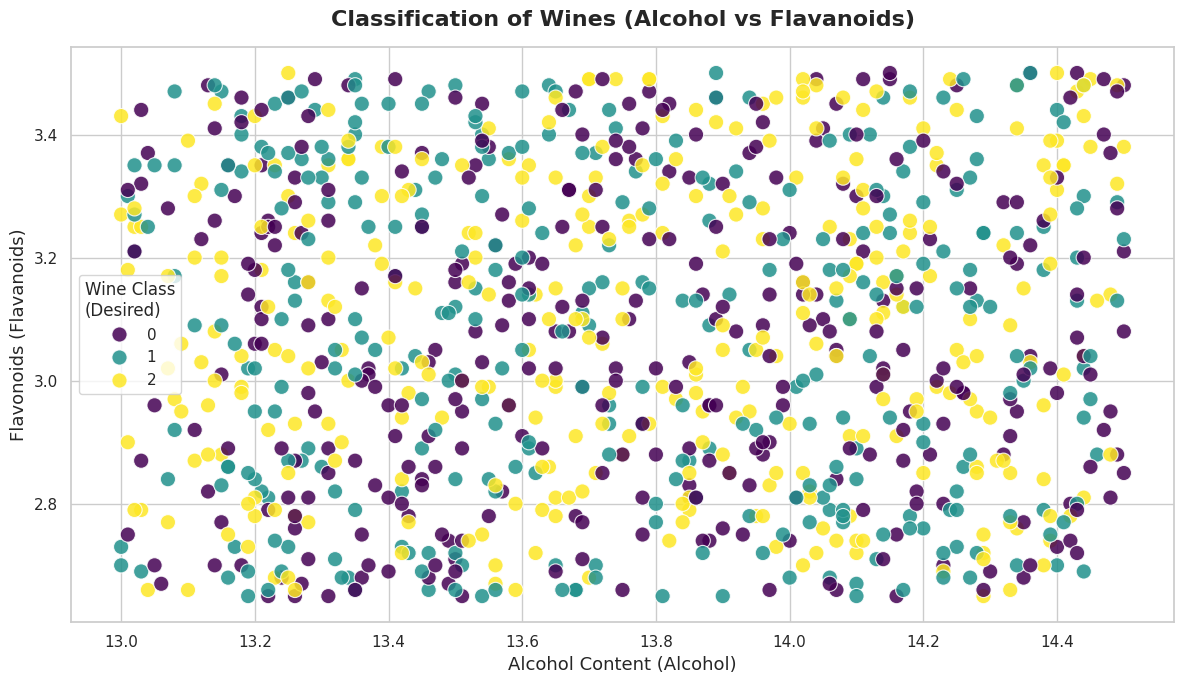

In [25]:
sns.set_theme(style = "whitegrid", palette = "muted")
plt.figure(figsize = (12, 7))
scatter = sns.scatterplot(
    data = wine_collection_df,
    x = 'Alcohol',
    y = 'Flavanoids',
    hue = 'Desired',
    palette = 'viridis',
    s = 120,
    alpha = 0.85,
    edgecolor = 'white',
    linewidth = 0.8
)
plt.title('Classification of Wines (Alcohol vs Flavanoids)', fontsize = 16, fontweight = 'bold', pad = 15)
plt.xlabel('Alcohol Content (Alcohol)', fontsize = 13)
plt.ylabel('Flavonoids (Flavanoids)', fontsize = 13)
plt.legend(title = 'Wine Class\n(Desired)', title_fontsize = '12', fontsize = '11', loc = 'best')
plt.tight_layout()
plt.show()

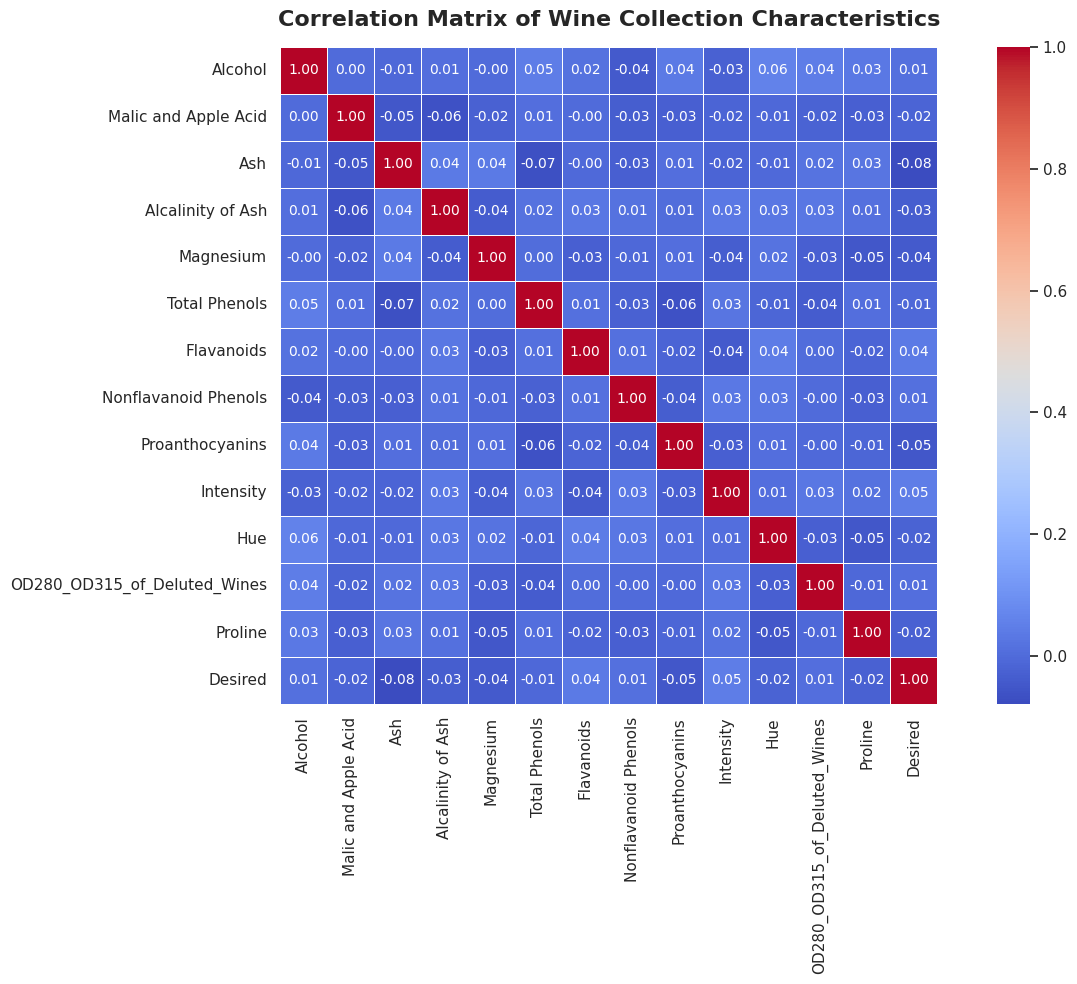

In [26]:
plt.figure(figsize = (14, 10))
sns.heatmap(
    wine_collection_df.corr(),
    annot = True,
    fmt = ".2f",
    cmap = 'coolwarm',
    cbar = True,
    square = True,
    linewidths = 0.5,
    annot_kws = { "size" : 10 }
)
plt.title('Correlation Matrix of Wine Collection Characteristics', fontsize = 16, fontweight = 'bold', pad = 15)
plt.tight_layout()
plt.show()